<a href="https://colab.research.google.com/github/phaniidk/ml-assessment-Nimmagadda-venkata-naga-Phanindra-/blob/main/part_a/q2_unsupervised_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving q2_customers.csv to q2_customers.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(500, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_per_month          500 non-null    int64
 3   basket_size               500 non-null    int64
 4   days_since_last_visit     500 non-null    int64
 5   num_categories_purchased  500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB
None
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [6]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

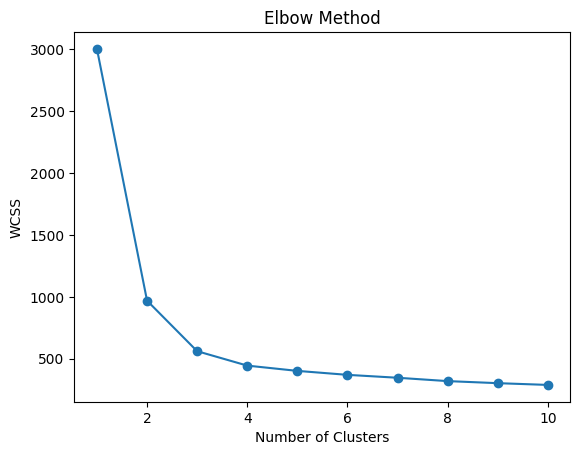

In [7]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [8]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

In [9]:
df['cluster'] = clusters
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [10]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


In [11]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [12]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [13]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)
loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


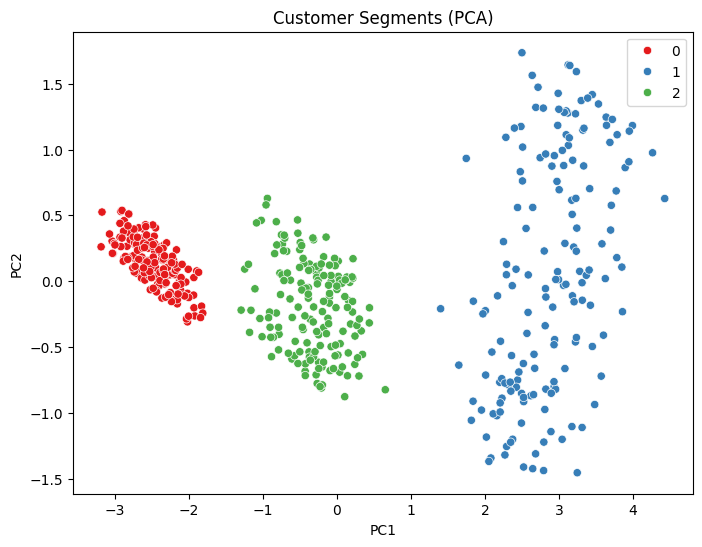

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df['cluster'],
    palette='Set1'
)
plt.title("Customer Segments (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()